# Task 2 - CNN Baselines
**Group: Group03** &nbsp;|&nbsp; **Dataset: PRBD (Processed Rice Bangladesh Dataset)** &nbsp;|&nbsp; **Track: 3 — CNN + Attention**

This notebook builds and fairly evaluates **4 representative CNN baselines** on the PRBD rice-variety
dataset, following directly from the Task 1 EDA:

- 10 classes, perfectly balanced (200 images/class, 2000 total), single resolution 640×480, no corrupt/duplicate files.
- **Only `Original_Images/`** is used to build the train/val/test split (same leakage-safety rule stated in Task 1).
  `Augmented_images/` is never touched — we generate our own augmentations on the training split only, here in Task 2.
- Since PRBD images are independent microscope photographs of grain samples (no repeated
  patient/subject/session per image), a **class-stratified random split** is the correct
  leakage-free split for this dataset (the §6.2 "split by subject" rule applies when multiple
  rows/images share an origin — that does not apply here, so stratified-by-class is used and
  documented explicitly as the leakage-safety decision for this dataset).

**Baselines built here (a representative 4, as required by the brief):**
1. **Simple CNN** — small custom conv-net trained from scratch (naive baseline).
2. **ResNet50** — classic deep transfer-learning backbone.
3. **MobileNetV2** — lightweight/efficient backbone.
4. **EfficientNet-B0** — modern efficient backbone.

Each baseline is trained with an **identical protocol** (same split, same augmentation, same
epoch budget, same optimizer family, early stopping) so that the final comparison table is fair.
The **splits are saved to disk** so that `task2_proposed_model.ipynb` reuses the *exact same*
train/val/test partition — required for an honest, leakage-free Pillar-A comparison later.

> Framework: **PyTorch** (chosen for straightforward custom-attention/CBAM implementation and
> Grad-CAM support needed in Task 3). Run on Kaggle with GPU + internet ON.


## 0. Setup

In [1]:
# ===== 0. SETUP =====
import os, glob, random, time, json, copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    os.system("pip install -q albumentations --no-deps")
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

import torchvision
from torchvision import models

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---- Paths (match Task 1) ----
BASE_PATH = "/kaggle/input/datasets/rejaul1111/prbd-dataset/Original_Images"
WORK_DIR = "/kaggle/working"
SPLIT_DIR = os.path.join(WORK_DIR, "splits")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
MODELS_DIR = os.path.join(WORK_DIR, "models")
for d in [SPLIT_DIR, RESULTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

CLASSES = sorted(os.listdir(BASE_PATH))
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
print(f"Found {NUM_CLASSES} classes:", CLASSES)

IMG_SIZE = 224  # standard input size for the transfer-learning backbones used below
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 6  # early stopping patience


Device: cuda
GPU: Tesla T4
Found 10 classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']


## 1. Build the file table (same as Task 1, `Original_Images` only)

In [2]:
records = []
for cls in CLASSES:
    cls_path = os.path.join(BASE_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        records.append({"class": cls, "label": CLASS_TO_IDX[cls], "filename": f,
                         "path": os.path.join(cls_path, f)})

df = pd.DataFrame(records)
print(f"Total images: {len(df)}")
df['class'].value_counts()


Total images: 2000


class
Aush             200
BR-28            200
BR-29            200
Beroi            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64

## 2. Leakage-free split — class-stratified 70/10/20 (train/val/test)

**Why this split is leakage-free for PRBD specifically:** the §6.2 rule requires splitting by
*subject/source* whenever several images share an origin (patient, recording session, host).
PRBD has no such repeated-origin structure — every file is one independent microscope shot of a
grain sample, and only `Original_Images` (never `Augmented_images`) is used to build the split, so
no near-duplicate augmented copy of a training image can leak into val/test. A **class-stratified**
split is therefore the correct leakage-safety choice here, keeping all 10 classes proportionally
represented in every split.

The split is saved to `splits/` so `task2_proposed_model.ipynb` loads the **identical** partition —
this guarantees the baseline-vs-proposed comparison later is apples-to-apples.


In [3]:
SPLIT_CSV = os.path.join(SPLIT_DIR, "group03_prbd_task2_split.csv")

if os.path.exists(SPLIT_CSV):
    print("Existing split found — reusing it for reproducibility.")
    split_df = pd.read_csv(SPLIT_CSV)
else:
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df['class'], random_state=SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=(2/3), stratify=temp_df['class'], random_state=SEED)  # 10% val, 20% test overall

    train_df = train_df.copy(); train_df['split'] = 'train'
    val_df = val_df.copy();     val_df['split'] = 'val'
    test_df = test_df.copy();   test_df['split'] = 'test'
    split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    split_df.to_csv(SPLIT_CSV, index=False)
    print("New split created and saved to", SPLIT_CSV)

print(split_df['split'].value_counts())
print()
print(pd.crosstab(split_df['class'], split_df['split']))


New split created and saved to /kaggle/working/splits/group03_prbd_task2_split.csv
split
train    1400
test      400
val       200
Name: count, dtype: int64

split          test  train  val
class                          
Aush             40    140   20
BR-28            40    140   20
BR-29            40    140   20
Beroi            40    140   20
Chinigura        40    140   20
Ghee Bhog        40    140   20
Katari Najir     40    140   20
Katari Siddho    40    140   20
Miniket          40    140   20
Swarna           40    140   20


In [4]:
train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df   = split_df[split_df['split'] == 'val'].reset_index(drop=True)
test_df  = split_df[split_df['split'] == 'test'].reset_index(drop=True)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# Sanity check: no filename overlap across splits (no leakage)
assert set(train_df['path']) & set(val_df['path']) == set()
assert set(train_df['path']) & set(test_df['path']) == set()
assert set(val_df['path']) & set(test_df['path']) == set()
print("Leakage check passed: train/val/test paths are disjoint.")


train=1400  val=200  test=400
Leakage check passed: train/val/test paths are disjoint.


## 3. Preprocessing & augmentation

- **Resize** every image to 224×224 (matches Task 1's decision and the input size expected by all
  four pretrained backbones below).
- **Normalize** with ImageNet mean/std (required for the pretrained backbones; the Simple CNN also
  uses it for a fair, identical pipeline across all baselines).
- **Augment the training split only** (never val/test) — horizontal flip, small rotation,
  brightness/contrast jitter, hue/saturation jitter, and coarse dropout (cutout-style), which are
  strong, standard augmentations for texture-heavy microscope imagery without distorting grain shape.
- **Imbalance handling:** not required — Task 1 confirmed PRBD is perfectly balanced
  (200 images/class, ratio 1.00:1) — noted here explicitly rather than adding unnecessary
  class-weighting that Task 1 already ruled out.


Batches -> train: 44  val: 7  test: 13


/tmp/ipykernel_22/1888314083.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),


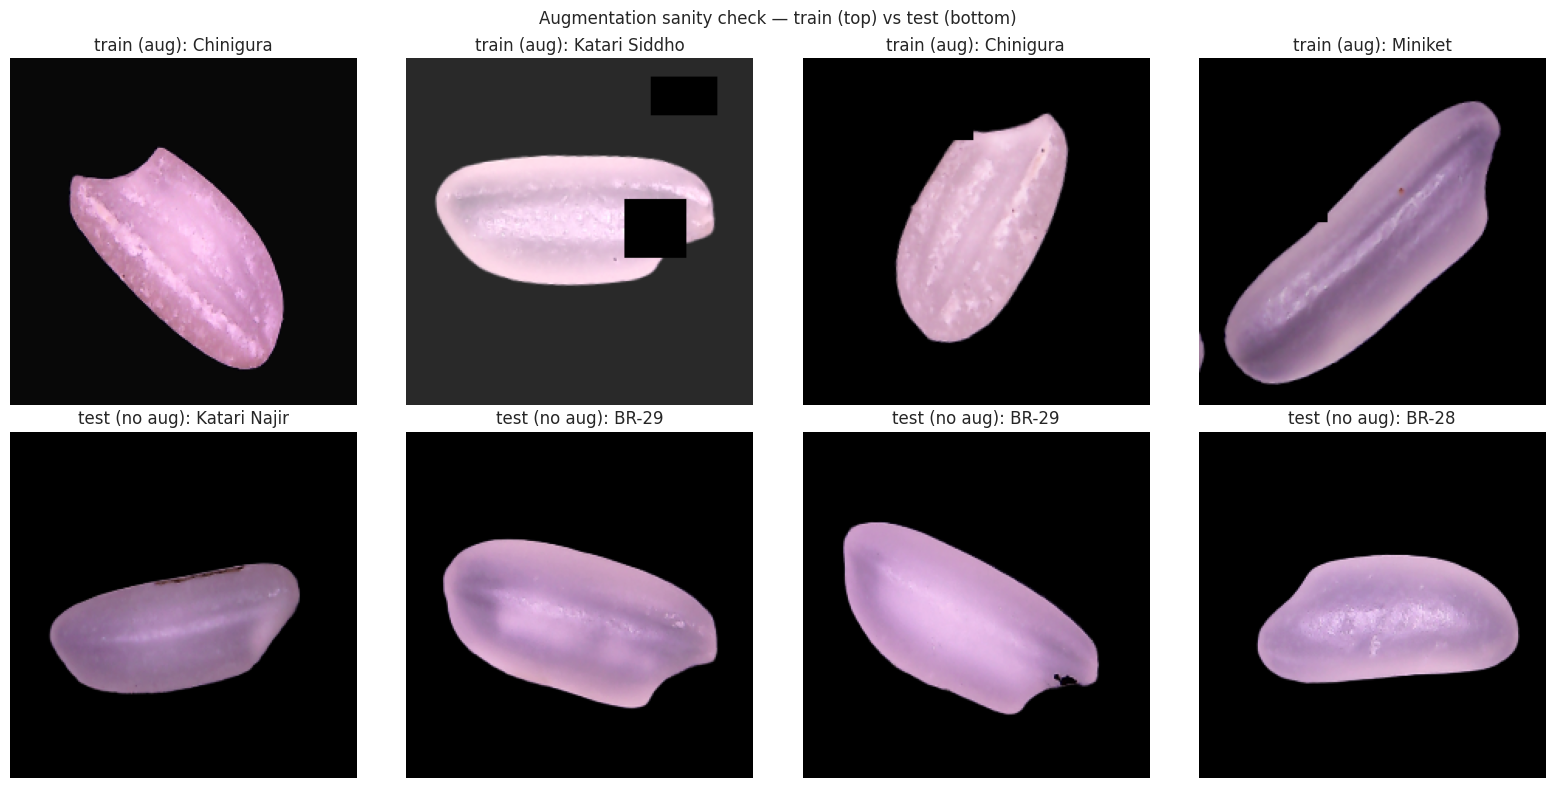

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class RiceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)
        img = augmented['image']
        return img, row['label']

train_ds = RiceDataset(train_df, train_transform)
val_ds   = RiceDataset(val_df, eval_transform)
test_ds  = RiceDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches -> train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

# Visual sanity check of augmentation
def denorm(img_t):
    img = img_t.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_raw, label = train_ds[i]
    axes[0, i].imshow(denorm(img_raw)); axes[0, i].set_title(f"train (aug): {IDX_TO_CLASS[label]}"); axes[0, i].axis('off')
    img_raw2, label2 = test_ds[i]
    axes[1, i].imshow(denorm(img_raw2)); axes[1, i].set_title(f"test (no aug): {IDX_TO_CLASS[label2]}"); axes[1, i].axis('off')
plt.suptitle("Augmentation sanity check — train (top) vs test (bottom)")
plt.tight_layout(); plt.show()


## 4. Shared training & evaluation utilities (identical protocol for every baseline)

In [6]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    tmp_path = "/tmp/_tmp_model_size.pth"
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return size_mb

def train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS, lr=1e-4, patience=PATIENCE):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc);   history['val_acc'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs).")
                break

    training_time = time.time() - start_time
    model.load_state_dict(best_state)
    torch.save(best_state, os.path.join(MODELS_DIR, f"{model_name}_best.pth"))
    return model, history, training_time


def evaluate_model(model, model_name, loader, class_names=CLASSES):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    start_time = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)
    inference_time = time.time() - start_time
    per_image_ms = (inference_time / len(loader.dataset)) * 1000

    all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)

    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    # One-vs-rest ROC-AUC (macro)
    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    roc_auc_per_class = {}
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc_per_class[class_names[i]] = auc(fpr, tpr)
    roc_auc_macro = np.mean(list(roc_auc_per_class.values()))

    metrics = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro, "recall_macro": recall_macro, "f1_macro": f1_macro,
        "precision_weighted": precision_weighted, "recall_weighted": recall_weighted, "f1_weighted": f1_weighted,
        "roc_auc_macro": roc_auc_macro,
        "inference_ms_per_image": per_image_ms,
        "n_params": count_params(model),
        "model_size_mb": model_size_mb(model),
    }

    print(f"\n===== {model_name} — Test set report =====")
    print(report)
    print(f"Accuracy={acc:.4f} | Macro-F1={f1_macro:.4f} | Weighted-F1={f1_weighted:.4f} | "
          f"Macro ROC-AUC={roc_auc_macro:.4f}")

    return metrics, all_labels, all_preds, all_probs, cm, report


def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.xticks(rotation=75); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc_pr_curves(all_labels, all_probs, class_names, title_prefix):
    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, lw=1, label=f"{cname} (AUC={roc_auc:.2f})")
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} — ROC curves (one-vs-rest)")
    axes[0].legend(fontsize=7, loc='lower right')

    for i, cname in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
        axes[1].plot(rec, prec, lw=1, label=cname)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} — Precision-Recall curves (one-vs-rest)")
    axes[1].legend(fontsize=7, loc='lower left')
    plt.tight_layout(); plt.show()


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(history['train_acc'], label='train'); axes[1].plot(history['val_acc'], label='val')
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

all_results = []   # collects the metrics dict from every baseline


## 5. Baseline 1 — Simple CNN (trained from scratch)

A small custom convolutional network with **no attention and no pretraining** — the naive
baseline every other model (including our Task 2 proposed model) must beat.


SimpleCNN trainable params: 423,562
[simple_cnn] Epoch 1/50 | train_loss=2.2076 train_acc=0.2229 | val_loss=2.0748 val_acc=0.4050
[simple_cnn] Epoch 2/50 | train_loss=2.0052 train_acc=0.3279 | val_loss=1.7978 val_acc=0.5500
[simple_cnn] Epoch 3/50 | train_loss=1.8601 train_acc=0.3893 | val_loss=1.6612 val_acc=0.5800
[simple_cnn] Epoch 4/50 | train_loss=1.7643 train_acc=0.4093 | val_loss=1.5661 val_acc=0.4150
[simple_cnn] Epoch 5/50 | train_loss=1.7011 train_acc=0.4000 | val_loss=1.4525 val_acc=0.5500
[simple_cnn] Epoch 6/50 | train_loss=1.5993 train_acc=0.4721 | val_loss=1.3510 val_acc=0.6400
[simple_cnn] Epoch 7/50 | train_loss=1.5584 train_acc=0.4829 | val_loss=1.2535 val_acc=0.6550
[simple_cnn] Epoch 8/50 | train_loss=1.4803 train_acc=0.5043 | val_loss=1.2302 val_acc=0.6600
[simple_cnn] Epoch 9/50 | train_loss=1.4416 train_acc=0.4957 | val_loss=1.1733 val_acc=0.6500
[simple_cnn] Epoch 10/50 | train_loss=1.3708 train_acc=0.5464 | val_loss=1.0959 val_acc=0.7300
[simple_cnn] Epoch 11/5

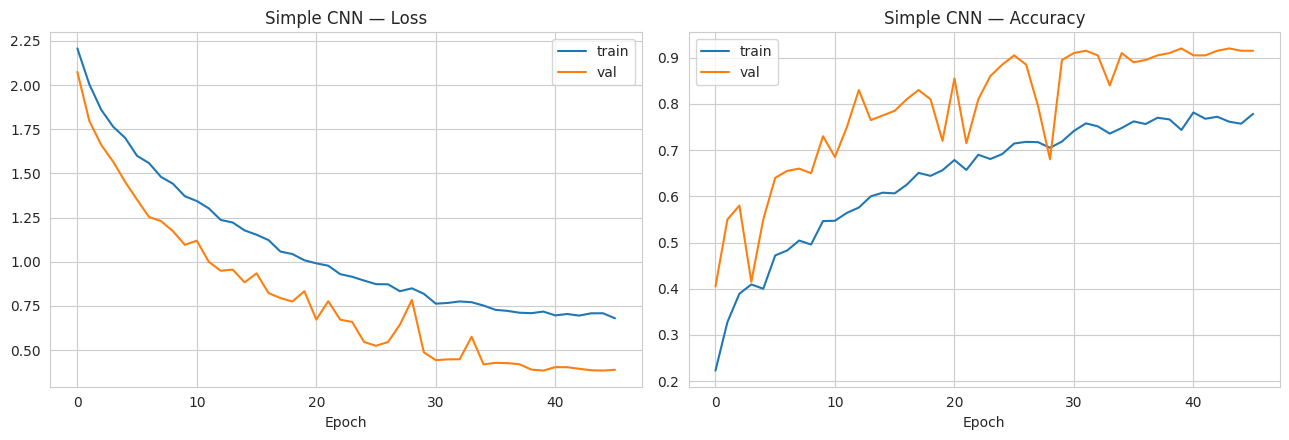

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),# 28
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),# 14
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)

model_simplecnn = SimpleCNN()
print(f"SimpleCNN trainable params: {count_params(model_simplecnn):,}")

model_simplecnn, hist_simplecnn, time_simplecnn = train_model(model_simplecnn, "simple_cnn", train_loader, val_loader)
plot_history(hist_simplecnn, "Simple CNN")



===== Simple CNN — Test set report =====
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.79      0.75      0.77        40
        BR-29       0.97      0.80      0.88        40
        Beroi       1.00      1.00      1.00        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.85      0.82      0.84        40
 Katari Najir       0.76      0.88      0.81        40
Katari Siddho       0.89      0.85      0.87        40
      Miniket       0.89      1.00      0.94        40
       Swarna       0.78      0.80      0.79        40

     accuracy                           0.89       400
    macro avg       0.89      0.89      0.89       400
 weighted avg       0.89      0.89      0.89       400

Accuracy=0.8900 | Macro-F1=0.8898 | Weighted-F1=0.8898 | Macro ROC-AUC=0.9936


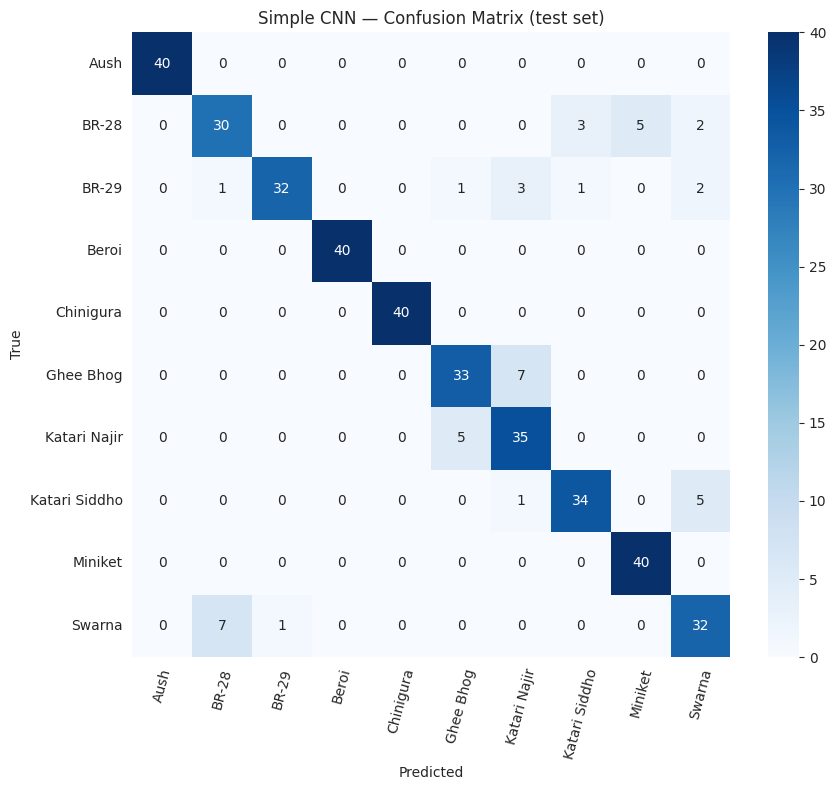

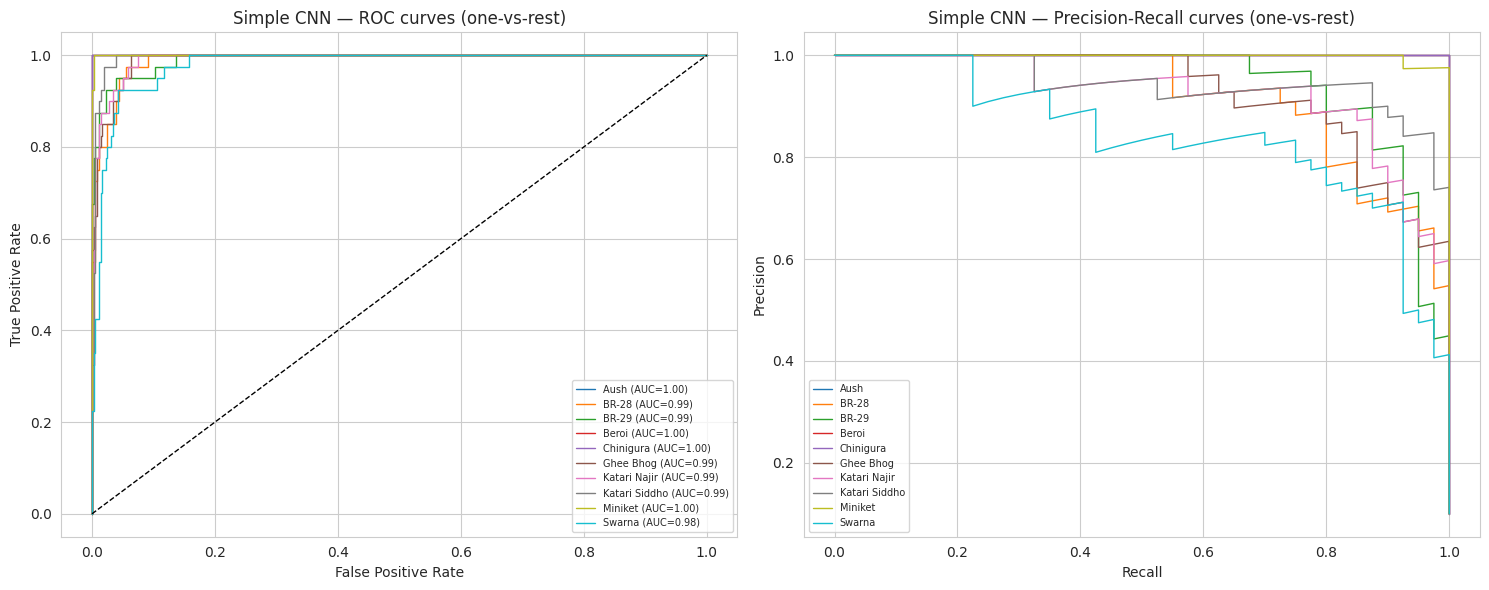

In [8]:
metrics_simplecnn, y_true_scnn, y_pred_scnn, y_prob_scnn, cm_scnn, report_scnn = evaluate_model(
    model_simplecnn, "Simple CNN", test_loader)
metrics_simplecnn["training_time_sec"] = time_simplecnn
plot_confusion_matrix(cm_scnn, CLASSES, "Simple CNN — Confusion Matrix (test set)")
plot_roc_pr_curves(y_true_scnn, y_prob_scnn, CLASSES, "Simple CNN")
all_results.append(metrics_simplecnn)


## 6. Baseline 2 — ResNet50 (ImageNet transfer learning)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


ResNet50 trainable params: 14,985,226
[resnet50] Epoch 1/50 | train_loss=2.0508 train_acc=0.4114 | val_loss=1.5690 val_acc=0.7250
[resnet50] Epoch 2/50 | train_loss=1.2740 train_acc=0.7336 | val_loss=0.7169 val_acc=0.8900
[resnet50] Epoch 3/50 | train_loss=0.6606 train_acc=0.8264 | val_loss=0.3692 val_acc=0.9000
[resnet50] Epoch 4/50 | train_loss=0.4462 train_acc=0.8671 | val_loss=0.2639 val_acc=0.9450
[resnet50] Epoch 5/50 | train_loss=0.3237 train_acc=0.9050 | val_loss=0.2047 val_acc=0.9500
[resnet50] Epoch 6/50 | train_loss=0.2467 train_acc=0.9264 | val_loss=0.2015 val_acc=0.9450
[resnet50] Epoch 7/50 | train_loss=0.2530 train_acc=0.9164 | val_loss=0.1728 val_acc=0.9450
[resnet50] Epoch 8/50 | train_loss=0.2448 train_acc=0.9229 | val_loss=0.1744 val_acc=0.9500
[resnet50] Epoch 9/50 | train_loss=0.1772 train_acc=0.9436 | val_loss=0.1261 val_acc=0.9650
[resnet50] Epoch 10/50 | train_loss=0.1521 train_acc=0.9521 | val_loss=0.1256 val_acc=0.9650
[resnet50] Epoch 11/50 | train_loss=0.154

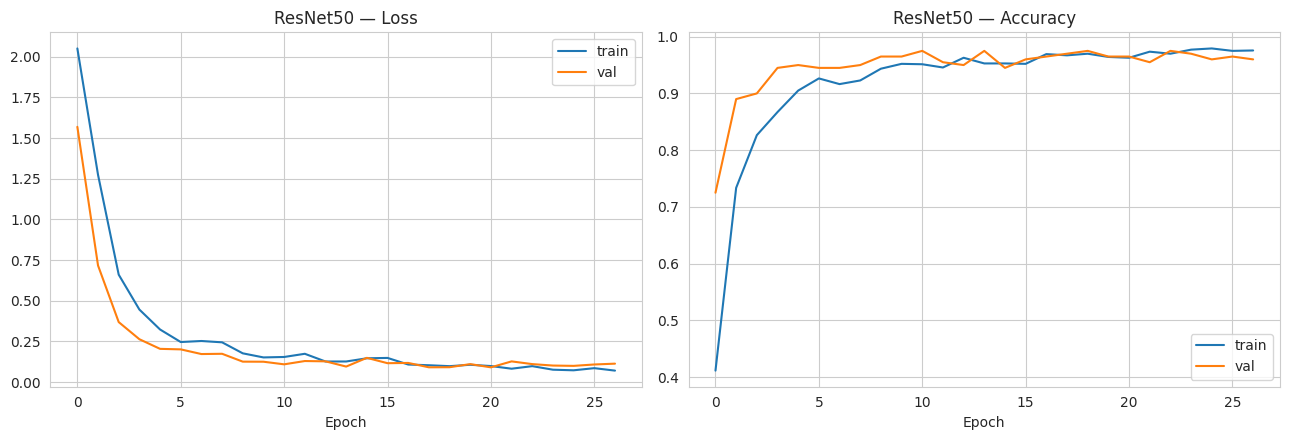

In [9]:
def build_resnet50():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in m.parameters():
        param.requires_grad = False
    for param in m.layer4.parameters():   # fine-tune only the last block + head
        param.requires_grad = True
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, NUM_CLASSES))
    return m

model_resnet50 = build_resnet50()
print(f"ResNet50 trainable params: {count_params(model_resnet50):,}")
model_resnet50, hist_resnet50, time_resnet50 = train_model(model_resnet50, "resnet50", train_loader, val_loader, lr=5e-5)
plot_history(hist_resnet50, "ResNet50")



===== ResNet50 — Test set report =====
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.95      0.90      0.92        40
        BR-29       0.97      0.90      0.94        40
        Beroi       1.00      1.00      1.00        40
    Chinigura       1.00      0.97      0.99        40
    Ghee Bhog       0.89      1.00      0.94        40
 Katari Najir       1.00      0.88      0.93        40
Katari Siddho       0.97      0.97      0.97        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.87      1.00      0.93        40

     accuracy                           0.96       400
    macro avg       0.97      0.96      0.96       400
 weighted avg       0.97      0.96      0.96       400

Accuracy=0.9625 | Macro-F1=0.9625 | Weighted-F1=0.9625 | Macro ROC-AUC=0.9990


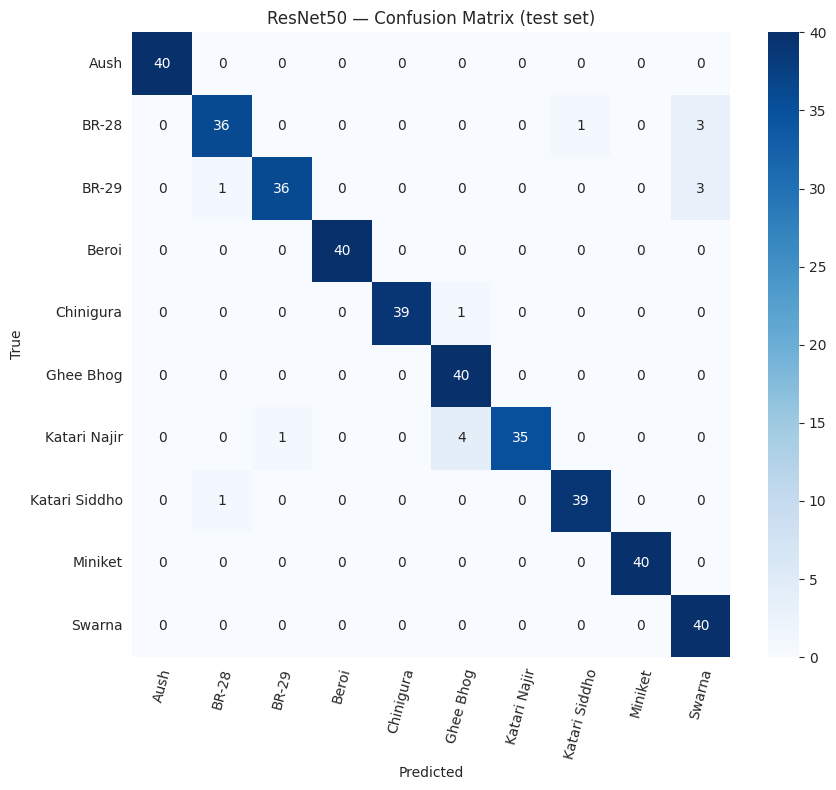

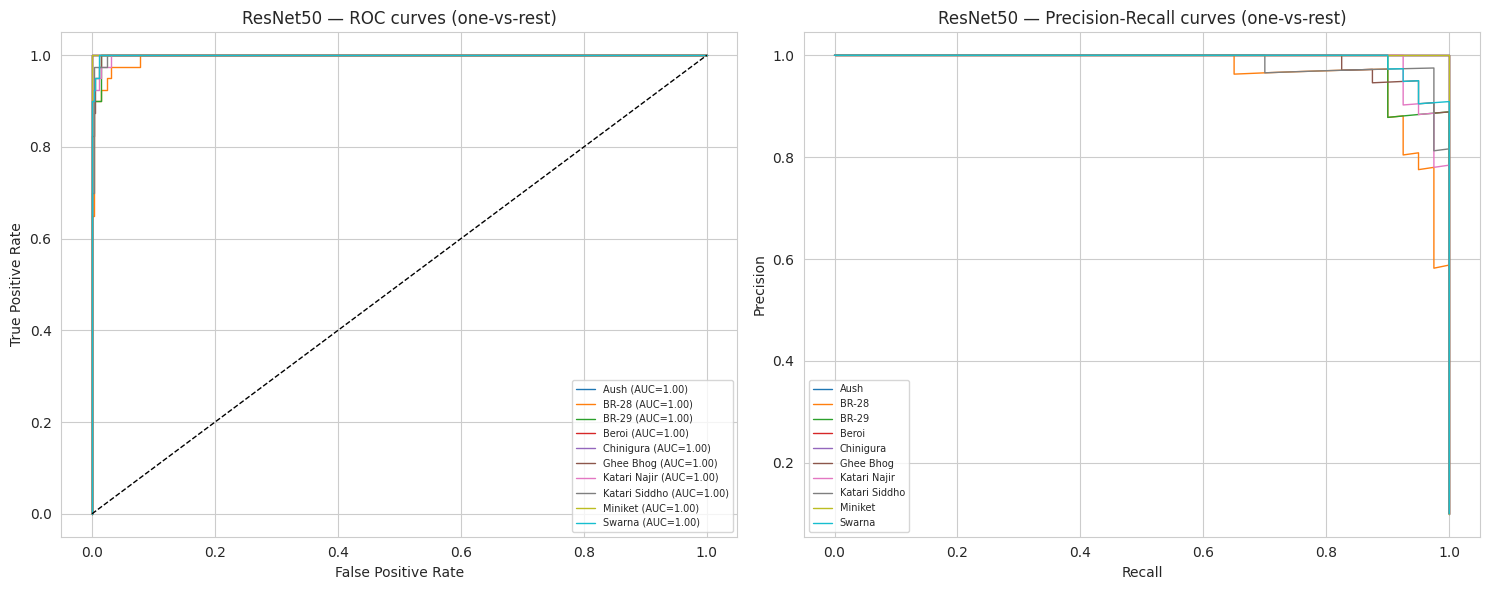

In [10]:
metrics_resnet50, y_true_r50, y_pred_r50, y_prob_r50, cm_r50, report_r50 = evaluate_model(
    model_resnet50, "ResNet50", test_loader)
metrics_resnet50["training_time_sec"] = time_resnet50
plot_confusion_matrix(cm_r50, CLASSES, "ResNet50 — Confusion Matrix (test set)")
plot_roc_pr_curves(y_true_r50, y_prob_r50, CLASSES, "ResNet50")
all_results.append(metrics_resnet50)


## 7. Baseline 3 — MobileNetV2 (lightweight transfer learning)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 65.4MB/s]

MobileNetV2 trainable params: 1,538,890


[mobilenet_v2] Epoch 1/50 | train_loss=1.9782 train_acc=0.4500 | val_loss=1.4715 val_acc=0.8050
[mobilenet_v2] Epoch 2/50 | train_loss=1.1710 train_acc=0.7693 | val_loss=0.6864 val_acc=0.8750
[mobilenet_v2] Epoch 3/50 | train_loss=0.6700 train_acc=0.8464 | val_loss=0.3993 val_acc=0.9050
[mobilenet_v2] Epoch 4/50 | train_loss=0.4804 train_acc=0.8671 | val_loss=0.2743 val_acc=0.9350
[mobilenet_v2] Epoch 5/50 | train_loss=0.3739 train_acc=0.8893 | val_loss=0.2273 val_acc=0.9400
[mobilenet_v2] Epoch 6/50 | train_loss=0.3164 train_acc=0.9086 | val_loss=0.1999 val_acc=0.9450
[mobilenet_v2] Epoch 7/50 | train_loss=0.2877 train_acc=0.9114 | val_loss=0.1966 val_acc=0.9250
[mobilenet_v2] Epoch 8/50 | train_loss=0.2440 train_acc=0.9329 | val_loss=0.1532 val_acc=0.9500
[mobilenet_v2] Epoch 9/50 | train_loss=0.2307 train_acc=0.9350 | val_loss=0.1570 val_acc=0.9450
[mobilenet_v2] Epoch 10/50 | train_loss=0.2266 train_acc=0.9179 | val_loss=0.1428 val_acc=0.9450
[mobilenet_v2] Epoch 11/50 | train_loss

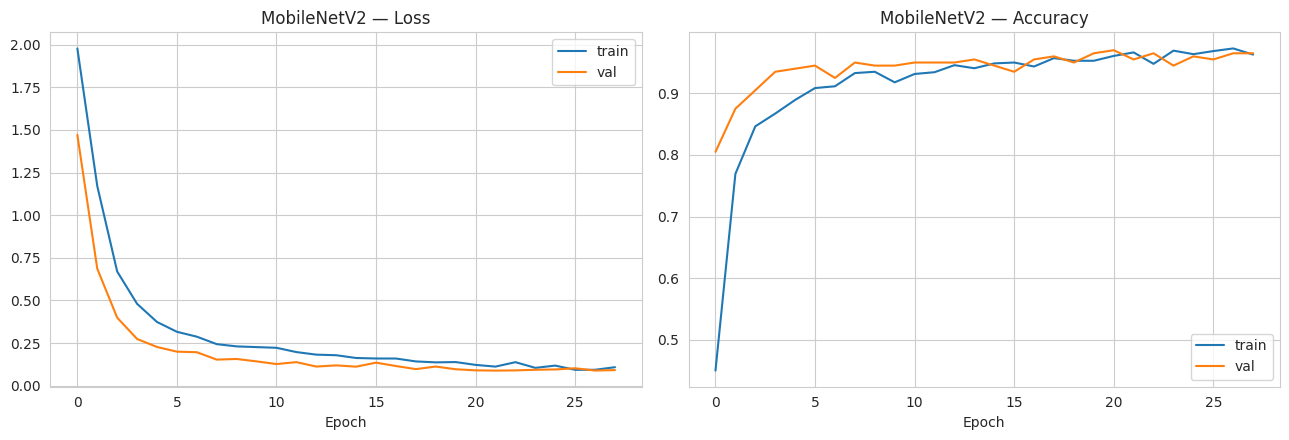

In [11]:
def build_mobilenetv2():
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[-4:].parameters():
        param.requires_grad = True
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.last_channel, NUM_CLASSES))
    return m

model_mobilenet = build_mobilenetv2()
print(f"MobileNetV2 trainable params: {count_params(model_mobilenet):,}")
model_mobilenet, hist_mobilenet, time_mobilenet = train_model(model_mobilenet, "mobilenet_v2", train_loader, val_loader, lr=1e-4)
plot_history(hist_mobilenet, "MobileNetV2")



===== MobileNetV2 — Test set report =====
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.95      0.88      0.91        40
        BR-29       0.97      0.93      0.95        40
        Beroi       1.00      1.00      1.00        40
    Chinigura       1.00      0.97      0.99        40
    Ghee Bhog       0.95      0.90      0.92        40
 Katari Najir       0.91      0.97      0.94        40
Katari Siddho       0.95      0.97      0.96        40
      Miniket       0.98      1.00      0.99        40
       Swarna       0.93      1.00      0.96        40

     accuracy                           0.96       400
    macro avg       0.96      0.96      0.96       400
 weighted avg       0.96      0.96      0.96       400

Accuracy=0.9625 | Macro-F1=0.9622 | Weighted-F1=0.9622 | Macro ROC-AUC=0.9983


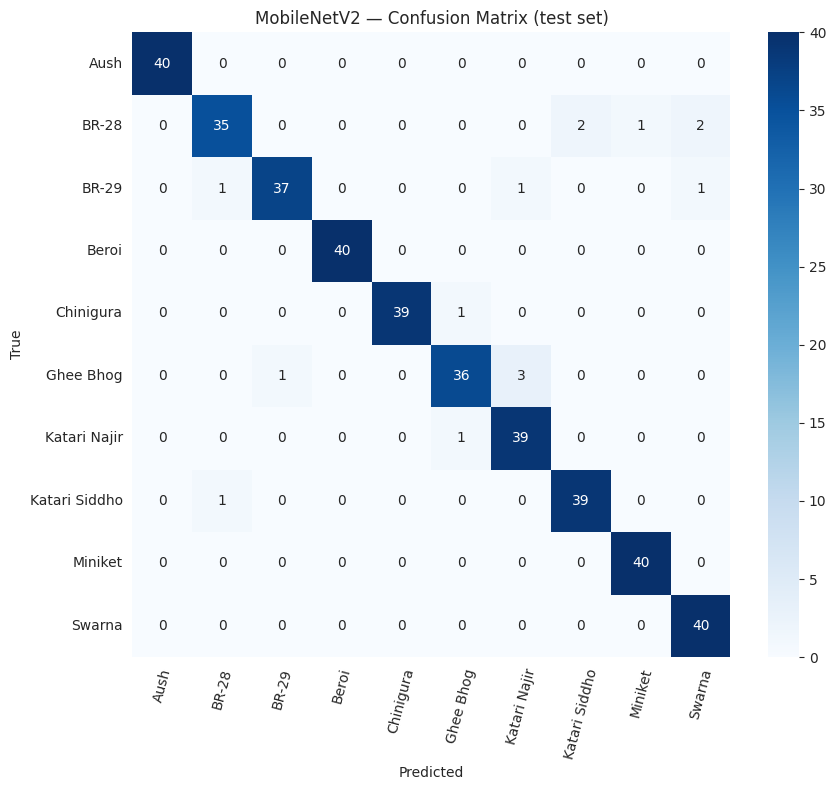

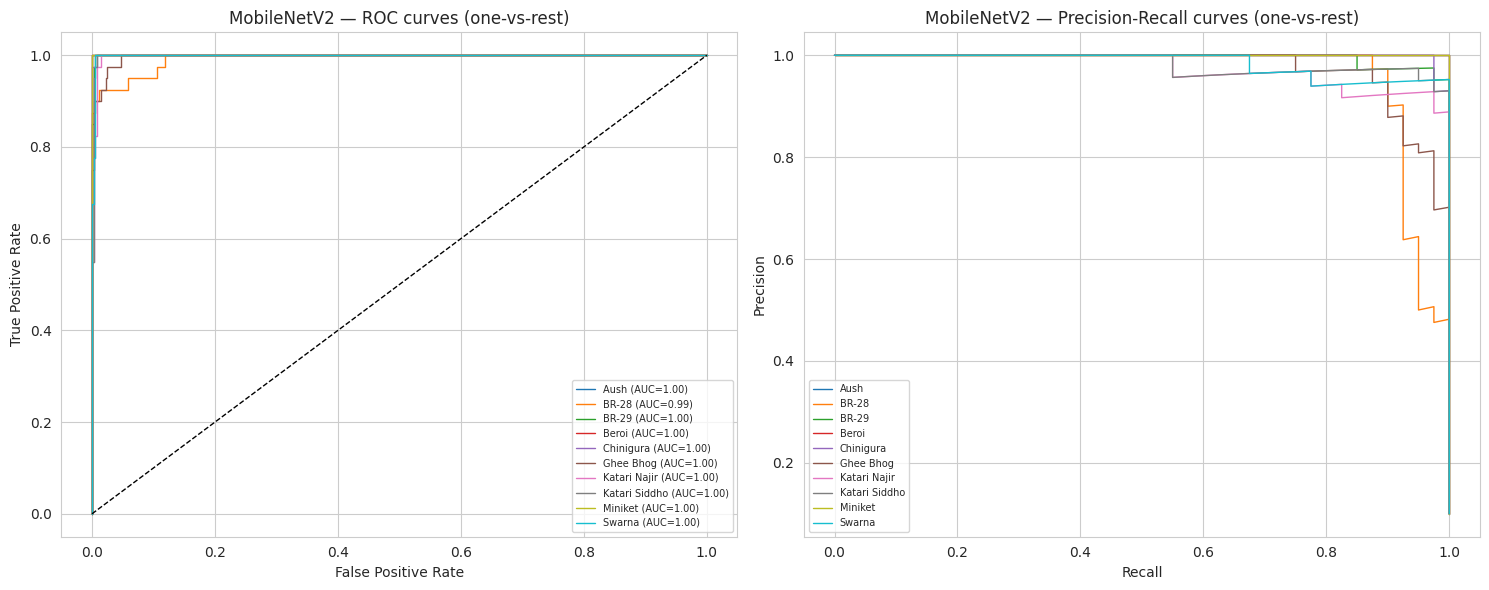

In [12]:
metrics_mobilenet, y_true_mnet, y_pred_mnet, y_prob_mnet, cm_mnet, report_mnet = evaluate_model(
    model_mobilenet, "MobileNetV2", test_loader)
metrics_mobilenet["training_time_sec"] = time_mobilenet
plot_confusion_matrix(cm_mnet, CLASSES, "MobileNetV2 — Confusion Matrix (test set)")
plot_roc_pr_curves(y_true_mnet, y_prob_mnet, CLASSES, "MobileNetV2")
all_results.append(metrics_mobilenet)


## 8. Baseline 4 — EfficientNet-B0 (modern efficient transfer learning)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s] 


EfficientNet-B0 trainable params: 3,168,550
[efficientnet_b0] Epoch 1/50 | train_loss=1.8661 train_acc=0.4857 | val_loss=1.0507 val_acc=0.7900
[efficientnet_b0] Epoch 2/50 | train_loss=1.0569 train_acc=0.7521 | val_loss=0.4050 val_acc=0.9100
[efficientnet_b0] Epoch 3/50 | train_loss=0.6089 train_acc=0.8429 | val_loss=0.2619 val_acc=0.9300
[efficientnet_b0] Epoch 4/50 | train_loss=0.4458 train_acc=0.8729 | val_loss=0.1951 val_acc=0.9400
[efficientnet_b0] Epoch 5/50 | train_loss=0.3542 train_acc=0.8893 | val_loss=0.1517 val_acc=0.9400
[efficientnet_b0] Epoch 6/50 | train_loss=0.3308 train_acc=0.8850 | val_loss=0.1191 val_acc=0.9600
[efficientnet_b0] Epoch 7/50 | train_loss=0.2568 train_acc=0.9207 | val_loss=0.0937 val_acc=0.9700
[efficientnet_b0] Epoch 8/50 | train_loss=0.2631 train_acc=0.9093 | val_loss=0.0873 val_acc=0.9700
[efficientnet_b0] Epoch 9/50 | train_loss=0.2546 train_acc=0.9121 | val_loss=0.1023 val_acc=0.9600
[efficientnet_b0] Epoch 10/50 | train_loss=0.2115 train_acc=0.927

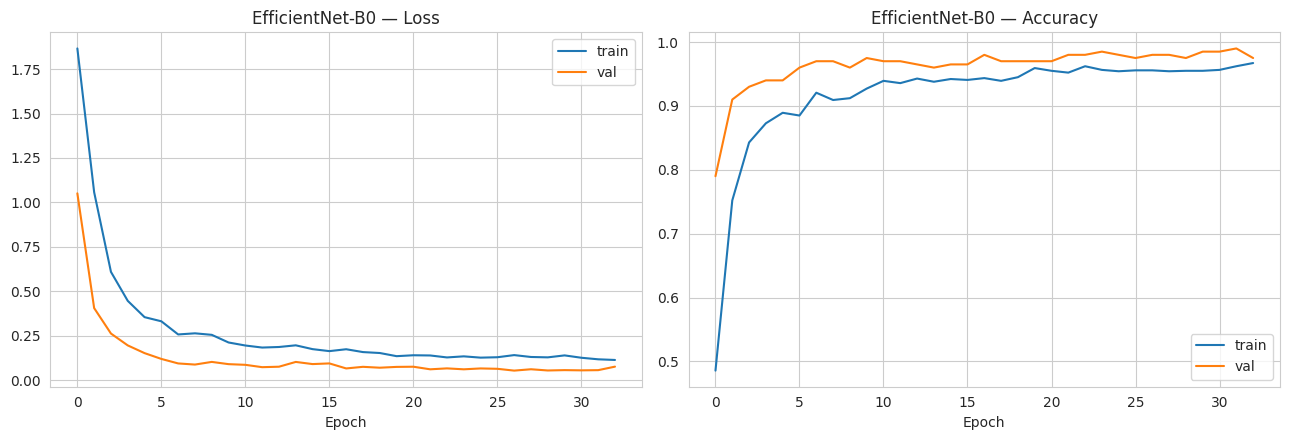

In [13]:
def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in m.parameters():
        param.requires_grad = False
    for param in m.features[-3:].parameters():
        param.requires_grad = True
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, NUM_CLASSES))
    return m

model_effnet = build_efficientnet_b0()
print(f"EfficientNet-B0 trainable params: {count_params(model_effnet):,}")
model_effnet, hist_effnet, time_effnet = train_model(model_effnet, "efficientnet_b0", train_loader, val_loader, lr=1e-4)
plot_history(hist_effnet, "EfficientNet-B0")



===== EfficientNet-B0 — Test set report =====
               precision    recall  f1-score   support

         Aush       1.00      0.95      0.97        40
        BR-28       0.97      0.90      0.94        40
        BR-29       0.97      0.95      0.96        40
        Beroi       0.98      1.00      0.99        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.84      0.93      0.88        40
 Katari Najir       0.92      0.82      0.87        40
Katari Siddho       0.97      0.97      0.97        40
      Miniket       0.98      1.00      0.99        40
       Swarna       0.91      1.00      0.95        40

     accuracy                           0.95       400
    macro avg       0.95      0.95      0.95       400
 weighted avg       0.95      0.95      0.95       400

Accuracy=0.9525 | Macro-F1=0.9524 | Weighted-F1=0.9524 | Macro ROC-AUC=0.9985


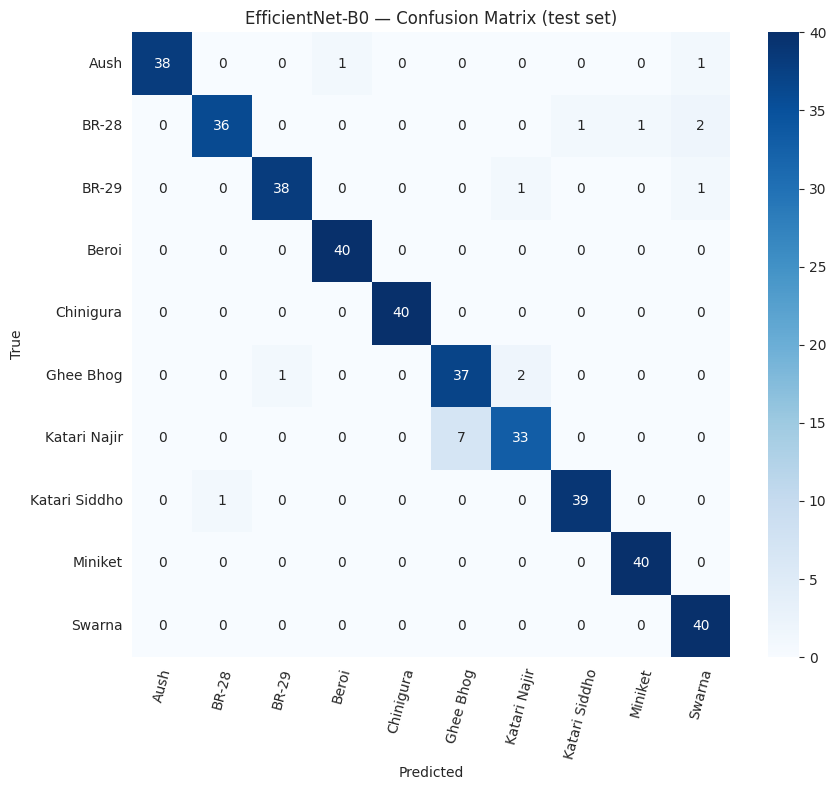

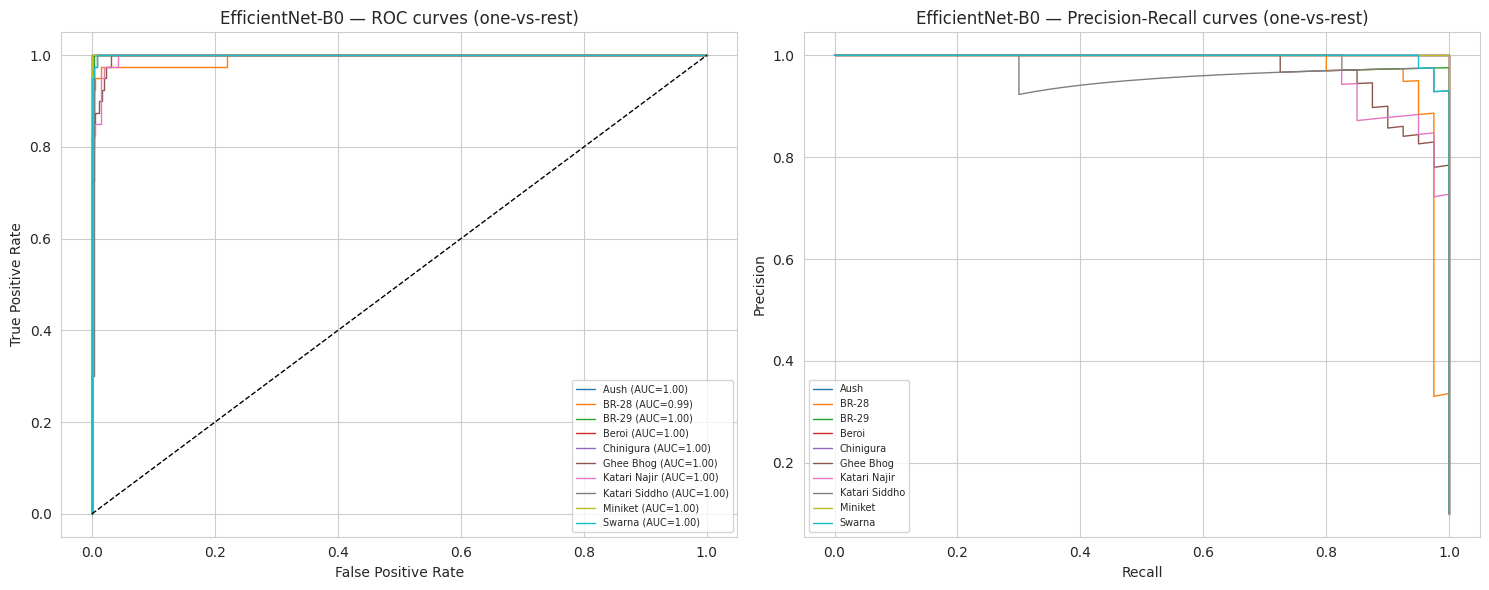

In [14]:
metrics_effnet, y_true_eff, y_pred_eff, y_prob_eff, cm_eff, report_eff = evaluate_model(
    model_effnet, "EfficientNet-B0", test_loader)
metrics_effnet["training_time_sec"] = time_effnet
plot_confusion_matrix(cm_eff, CLASSES, "EfficientNet-B0 — Confusion Matrix (test set)")
plot_roc_pr_curves(y_true_eff, y_prob_eff, CLASSES, "EfficientNet-B0")
all_results.append(metrics_effnet)


## 9. Baseline comparison table

In [15]:
results_df = pd.DataFrame(all_results)
col_order = ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro",
             "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc_macro",
             "training_time_sec", "inference_ms_per_image", "n_params", "model_size_mb"]
results_df = results_df[col_order].sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df.round(4)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro,training_time_sec,inference_ms_per_image,n_params,model_size_mb
0,ResNet50,0.9625,0.9654,0.9625,0.9625,0.9654,0.9625,0.9625,0.9990,273.6896,6.2503,14985226,90.0600
1,MobileNetV2,0.9625,0.9631,0.9625,0.9622,0.9631,0.9625,0.9622,0.9983,251.3533,6.4339,1538890,8.7680
2,EfficientNet-B0,0.9525,0.9540,0.9525,0.9524,0.9540,0.9525,0.9524,0.9985,311.4798,5.8631,3168550,15.6238
3,Simple CNN,0.8900,0.8930,0.8900,0.8898,0.8930,0.8900,0.8898,0.9936,441.2343,8.5681,423562,1.6304


/tmp/ipykernel_22/668244765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="f1_macro", palette="viridis", ax=ax)


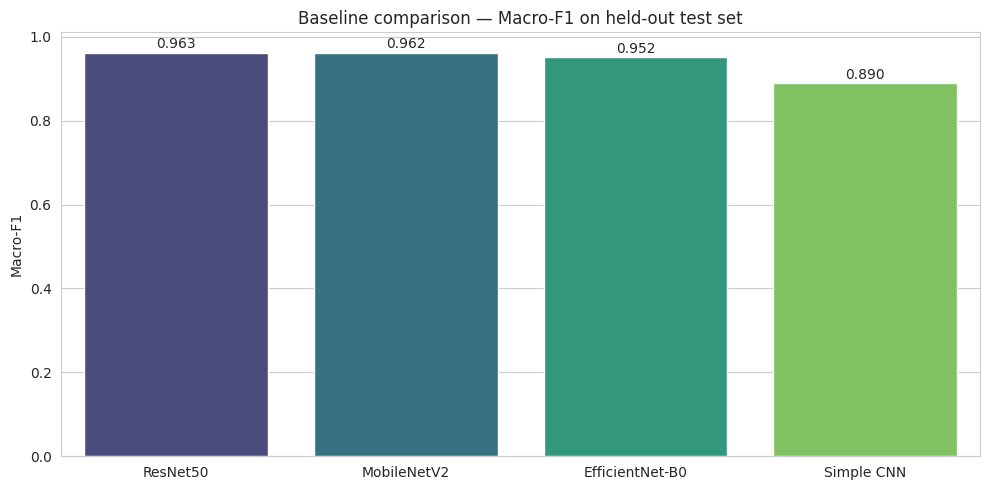

BASELINE TO BEAT: ResNet50  (Macro-F1 = 0.9625)


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=results_df, x="model", y="f1_macro", palette="viridis", ax=ax)
ax.set_title("Baseline comparison — Macro-F1 on held-out test set")
ax.set_ylabel("Macro-F1"); ax.set_xlabel("")
for i, v in enumerate(results_df['f1_macro']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout(); plt.show()

best_baseline = results_df.iloc[0]['model']
best_baseline_f1 = results_df.iloc[0]['f1_macro']
print(f"BASELINE TO BEAT: {best_baseline}  (Macro-F1 = {best_baseline_f1:.4f})")


ResNet50 serves as the strongest baseline (Macro-F1 = 0.9625), with MobileNetV2 performing almost identically (0.9622). Both transfer learning models significantly outperform the from-scratch Simple CNN (Macro-F1 = 0.8898). Consequently, 0.9625 represents the target benchmark that the proposed CBAM model must surpass.


## 10. Save all baseline results (for reuse by the proposed-model notebook and later Task 3)

In [17]:
results_df.to_csv(os.path.join(RESULTS_DIR, "group03_prbd_task2_baseline_results.csv"), index=False)

with open(os.path.join(RESULTS_DIR, "group03_prbd_task2_baseline_results.json"), "w") as f:
    json.dump(all_results, f, indent=2, default=float)

with open(os.path.join(RESULTS_DIR, "group03_prbd_task2_best_baseline.json"), "w") as f:
    json.dump({"best_baseline": best_baseline, "best_baseline_f1_macro": float(best_baseline_f1)}, f, indent=2)

print("Saved:")
print(" -", os.path.join(RESULTS_DIR, "group03_prbd_task2_baseline_results.csv"))
print(" -", os.path.join(RESULTS_DIR, "group03_prbd_task2_baseline_results.json"))
print(" -", os.path.join(RESULTS_DIR, "group03_prbd_task2_best_baseline.json"))
print(" -", SPLIT_CSV, " (train/val/test split, reused by the proposed-model notebook)")
print(" -", MODELS_DIR, " (best .pth checkpoint per baseline)")


Saved:
 - /kaggle/working/results/group03_prbd_task2_baseline_results.csv
 - /kaggle/working/results/group03_prbd_task2_baseline_results.json
 - /kaggle/working/results/group03_prbd_task2_best_baseline.json
 - /kaggle/working/splits/group03_prbd_task2_split.csv  (train/val/test split, reused by the proposed-model notebook)
 - /kaggle/working/models  (best .pth checkpoint per baseline)


## Summary — carried into `task2_proposed_model.ipynb` and the Task 2 report

- Leakage-free, class-stratified 70/10/20 split built on `Original_Images` only; saved to `splits/` for reuse.
- Identical preprocessing/augmentation protocol used for every baseline (fair comparison).
- 4 representative baselines trained: Simple CNN (scratch), ResNet50, MobileNetV2, EfficientNet-B0.
- Full metric set reported per baseline: accuracy, macro/weighted precision-recall-F1, macro ROC-AUC,
  confusion matrix, ROC & PR curves, training time, per-image inference time, parameter count, model size.
- **Baseline-to-beat identified by macro-F1** — carried forward as the target for the attention model.
- All results, checkpoints, and the split are saved to `/kaggle/working/` so the proposed-model
  notebook can load them directly without re-deriving anything (no leakage risk from re-splitting).
